In [30]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv("/home/cmp/Documents/Github/Stoner-SCF/out/find_gs.csv")
# Filtered Unconverged
df = df[np.abs(df['Energy']) > 1e-3]
df.head()

,Seed,Energy,Threshold,Rho2Trace,O1_Lx,O1_Ly,O1_Lz,O1_L110,O1_Sx,O1_Sy,...,occ1_zx_up,occ1_zx_down,occ1_xy_up,occ1_xy_down,occ2_yz_up,occ2_yz_down,occ2_zx_up,occ2_zx_down,occ2_xy_up,occ2_xy_down
0,0,39.683162,1.000000e-07,9.576255,-2.158416e-08,-3.641209e-08,-1.880992e-03,-4.100954e-08,-0.402208,-0.174740,...,0.981568,0.941961,0.789736,0.337913,0.888442,0.648755,0.888441,0.648755,0.988164,0.962734
1,1,39.683162,1.000000e-07,9.576255,-1.192153e-10,5.939308e-11,5.396694e-04,-4.230069e-11,-0.437144,-0.240723,...,0.970515,0.953015,0.663644,0.464005,0.821568,0.715629,0.821567,0.715629,0.981069,0.969829
2,2,39.684678,1.000000e-07,9.504531,-6.239493e-11,-2.022252e-08,-1.490079e-08,-1.434360e-08,0.025060,0.470027,...,0.963687,0.978795,0.456697,0.682740,0.464905,0.687575,0.888364,0.934819,0.999991,0.999995
3,3,39.684678,1.000000e-06,9.504531,-5.976273e-09,-2.753340e-08,1.244024e-08,-2.369491e-08,-0.068699,0.206089,...,0.996991,0.945491,0.954980,0.184457,0.955674,0.196807,0.990752,0.832431,0.999999,0.999986
5,5,39.683162,1.000000e-05,9.576255,6.216999e-09,1.109773e-08,1.347329e-03,1.224336e-08,0.090535,0.473068,...,0.948672,0.974858,0.414465,0.713184,0.689359,0.847838,0.689359,0.847838,0.967042,0.983856


In [32]:
# Functions for density matrix
def parse_rho(cell: str, n: int = 12) -> np.ndarray:
    """Parse a flattened 'real imag real imag ...' string into an n x n complex matrix."""
    flat = np.fromstring(cell, sep=' ')          # 288 floats
    real = flat[0::2]
    imag = flat[1::2]
    return (real + 1j * imag).reshape(n, n)

def print_complex_matrix(M, precision=2, width=6):
    fmt = f"{{:{width}.{precision}f}}{{:+.{precision}f}}j"
    for row in M:
        print("  ".join(fmt.format(x.real, x.imag) for x in row))


# Compute observables from density matrix
# Layer, Spin, Orbital Ordering
def compute_observables(rho: np.ndarray) -> dict:

    eLz = np.trace(np.kron(I2, np.kron(I2, Lz)) @ rho).real
    print(eLz)
    return 0


In [33]:
print(df.columns)

Index(['Seed', 'Energy', 'Threshold', 'Rho2Trace', 'O1_Lx', 'O1_Ly', 'O1_Lz',
       'O1_L110', 'O1_Sx', 'O1_Sy', 'O1_Sz', 'O1_S110', 'O2_Lx', 'O2_Ly',
       'O2_Lz', 'O2_L110', 'O2_Sx', 'O2_Sy', 'O2_Sz', 'O2_S110', 'occ1_yz_up',
       'occ1_yz_down', 'occ1_zx_up', 'occ1_zx_down', 'occ1_xy_up',
       'occ1_xy_down', 'occ2_yz_up', 'occ2_yz_down', 'occ2_zx_up',
       'occ2_zx_down', 'occ2_xy_up', 'occ2_xy_down '],
      dtype='str')


In [45]:
df = df.sort_values(by="Energy", ascending=True)
df.columns = df.columns.str.strip()

orbitals = ["yz", "zx", "xy"]
spins = ["up", "down"]
layers = [1, 2]
moment_labels = ["Lx", "Ly", "Lz", "L110", "Sx", "Sy", "Sz", "S110"]

# --- Formatted text summaries ---

def occupation_table(row):
    data = {}
    for layer in layers:
        for spin in spins:
            data[f"L{layer} {spin}"] = [row[f"occ{layer}_{orb}_{spin}"] for orb in orbitals]
    t = pd.DataFrame(data, index=orbitals)
    t["L1 tot"] = t["L1 up"] + t["L1 down"]
    t["L2 tot"] = t["L2 up"] + t["L2 down"]
    t.loc["Total"] = t.sum()
    return t

def moment_table(row):
    data = {
        "Layer 1": [row[f"O1_{lab}"] for lab in moment_labels],
        "Layer 2": [row[f"O2_{lab}"] for lab in moment_labels],
    }
    return pd.DataFrame(data, index=moment_labels)

def print_seed_summary(row):
    print(f"\n===== Seed {int(row['Seed'])}  "
            f"(E = {row['Energy']:.6f}, Threshold = {row['Threshold']:.1e}, "
            f"Rho2Trace = {row['Rho2Trace']:.6f}) =====")
    print("\nOccupations:")
    print(occupation_table(row).round(4).to_string())
    print("\nOrbital (L) and spin (S) moments:")
    print(moment_table(row).round(4).to_string())

print_seed_summary(df.iloc[0])
print("=================")
print(df.iloc[0]["Seed"])


===== Seed 0  (E = 39.683162, Threshold = 1.0e-07, Rho2Trace = 9.576255) =====

Occupations:
        L1 up  L1 down   L2 up  L2 down  L1 tot  L2 tot
yz     0.9816   0.9420  0.8884   0.6488  1.9235  1.5372
zx     0.9816   0.9420  0.8884   0.6488  1.9235  1.5372
xy     0.7897   0.3379  0.9882   0.9627  1.1276  1.9509
Total  2.7529   2.2218  2.7650   2.2602  4.9747  5.0253

Orbital (L) and spin (S) moments:
      Layer 1  Layer 2
Lx    -0.0000   0.0000
Ly    -0.0000   0.0000
Lz    -0.0019   0.6608
L110  -0.0000   0.0000
Sx    -0.4022  -0.3824
Sy    -0.1747  -0.1661
Sz     0.2655   0.2524
S110  -0.4080  -0.3879
0.0


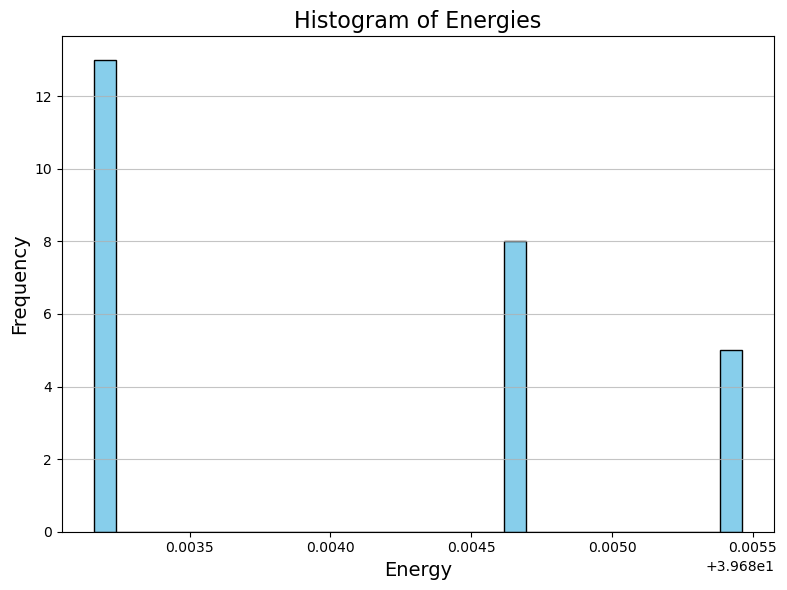

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df['Energy'], bins=30, color='skyblue', edgecolor='black')

ax.set_title('Histogram of Energies', fontsize=16)
ax.set_xlabel('Energy', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

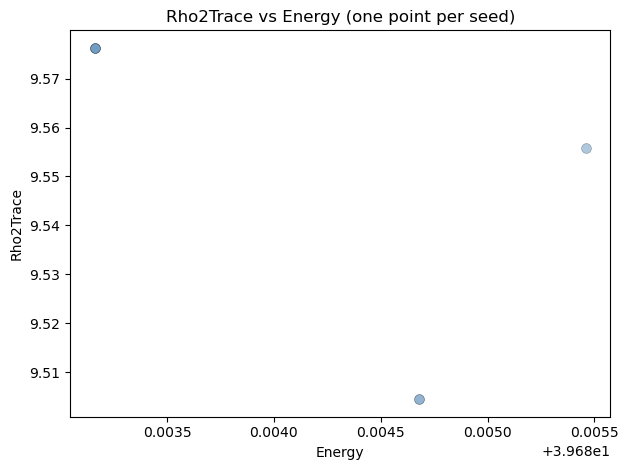

In [36]:
# --- Scatter: Energy vs Rho2Trace, one point per seed ---
fig, ax = plt.subplots()

ax.scatter(
    df["Energy"],
    df["Rho2Trace"],
    s=50,
    alpha=0.1,
    edgecolor="black",
    linewidth=0.3,
    color="steelblue",
)

ax.set_xlabel("Energy")
ax.set_ylabel("Rho2Trace")
ax.set_title("Rho2Trace vs Energy (one point per seed)")

plt.tight_layout()
plt.savefig("energy_vs_rho2trace_scatter.png", dpi=150)
plt.show()